# Resolução de Killer Sudoku via Programação Linear Inteira (PLI)

> **Origem do Projeto**: Resolução de um exercício prático proposto no curso de **Ciência de Dados e Pesquisa Operacional (CDPO) da Universidade de São Paulo (USP)**.

---

## 1. Visão Geral do Problema

O **Killer Sudoku** é uma das variações combinatórias mais desafiadoras do Sudoku clássico. Além das regras tradicionais do tabuleiro $9 \times 9$, o grid é particionado em subconjuntos contíguos de células denominados **gaiolas** (*cages*).

### Motivação do Projeto
A resolução do **Killer Sudoku** via Pesquisa Operacional vai além do desafio puramente lúdico: trata-se de um modelo paradigmático de **Satisfatibilidade de Restrições (CSP) e Otimização Discreta**.

- **Superando a Explosão Combinatória**: Em um espaço de busca bruto de ordem astronômica ($9^{81} \approx 1.96 \times 10^{77}$ combinações possíveis), algoritmos ingênuos de tentativa e erro (*backtracking*) demandam tempo exponencial. A Programação Linear Inteira (PLI), por meio do método de *Branch-and-Cut* e planos de corte de Gomory, poda de forma inteligente o espaço viável e encontra o ótimo global comprovado em **menos de 1 segundo**.
- **Ponte Direta com Aplicações Industriais Reais**: A exata mesma formulação com tensores de variáveis binárias ($x_{i, j, k} \in \{0, 1\}$) e restrições canônicas de atribuição única e limites de soma é a base de problemas industriais de grande escala, tais como:
  - **Escala de Tripulações (*Crew Scheduling*)**: Alocação ótima de pilotos e equipes respeitando normas regulatórias e jornadas de trabalho;
  - **Alocação de Horários (*Timetabling*)**: Criação de grades horárias escolares e acadêmicas sem conflitos de salas e professores;
  - **Roteamento de Veículos com Janelas de Tempo (VRPTW)**: Otimização logística de entregas sob restrições estritas de capacidade;
  - **Telecomunicações**: Alocação de frequências e espectro sem interferências cruzadas.
- **Reprodutibilidade Aberta**: Demonstração prática do uso de solvers livres de alta performance (**Coin-OR CBC** via biblioteca **PuLP**) sem dependência de softwares proprietários ou licenças comerciais.

### Regras do Killer Sudoku:
1. Cada célula deve receber um único dígito inteiro entre $1$ e $9$.
2. Cada **linha** deve conter todos os dígitos de $1$ a $9$ sem repetição.
3. Cada **coluna** deve conter todos os dígitos de $1$ a $9$ sem repetição.
4. Cada **subgrade $3 \times 3$** deve conter todos os dígitos de $1$ a $9$ sem repetição.
5. Cada **gaiola** (*cage*) possui uma soma pré-definida no canto superior: a soma dos números de suas células deve totalizar exatamente esse valor.
6. Em uma mesma gaiola, **nenhum dígito pode se repetir**.


In [1]:
import itertools as it
import warnings
import matplotlib.pyplot as pp
import numpy as np
import pulp

warnings.filterwarnings('ignore')
%matplotlib inline


## 2. Formulação Matemática como PLI

Para a modelagem matemática do problema, estrutura-se um tensor tridimensional de variáveis de decisão binárias:

$$x_{i, j, k} \in \{0, 1\}, \quad \forall i, j \in \{0, \dots, 8\}, \quad k \in \{0, \dots, 8\}$$

onde:
$$x_{i, j, k} = 1 \iff \text{a célula na linha } i \text{ e coluna } j \text{ contém o número } (k + 1)$$

O total de variáveis binárias é $9 \times 9 \times 9 = 729$.

### Restrições Matemáticas:

1. **Unicidade de Célula** (exatamente um valor por coordenada):
   $$\sum_{k=0}^{8} x_{i, j, k} = 1, \quad \forall i, j \in \{0, \dots, 8\}$$

2. **Unicidade de Linha** (cada número aparece uma única vez por linha):
   $$\sum_{j=0}^{8} x_{i, j, k} = 1, \quad \forall i, k \in \{0, \dots, 8\}$$

3. **Unicidade de Coluna** (cada número aparece uma única vez por coluna):
   $$\sum_{i=0}^{8} x_{i, j, k} = 1, \quad \forall j, k \in \{0, \dots, 8\}$$

4. **Unicidade de Bloco $3 \times 3$**:
   $$\sum_{i=0}^{2} \sum_{j=0}^{2} x_{3I + i, \, 3J + j, \, k} = 1, \quad \forall I, J \in \{0, 1, 2\}, \quad \forall k \in \{0, \dots, 8\}$$

5. **Unicidade Dentro da Gaiola** (não-repetição na mesma gaiola $C$):
   $$\sum_{(i, j) \in C} x_{i, j, k} \le 1, \quad \forall k \in \{0, \dots, 8\}, \quad \forall C \in \mathcal{C}$$

6. **Restrição de Soma da Gaiola**:
   $$\sum_{(i, j) \in C} \sum_{k=0}^{8} (k + 1) x_{i, j, k} = S_C, \quad \forall C \in \mathcal{C}$$


## 3. Função de Renderização Gráfica do Tabuleiro

A função `display_killersudoku` utiliza a biblioteca Matplotlib para renderizar o grid estrutural do tabuleiro, as bordas tracejadas delimitadoras de cada gaiola, os rótulos de soma e os dígitos preenchidos.


In [2]:
def display_killersudoku(dica=None, sol=None, cages=None, L=3, savefig=False, namefile='killersudoku.png'):
    """Renderiza graficamente o tabuleiro de Killer Sudoku com gaiolas, somas e valores."""
    pp.figure(figsize=(8, 8))
    pp.axis('off')

    # Desenho da grade do Sudoku
    for i in range(L**2 + 1):
        lw = 2.5 if i % L == 0 else 0.8
        pp.plot([0, L**2], [i, i], 'k', linewidth=lw)
        pp.plot([i, i], [0, L**2], 'k', linewidth=lw)

    # Inserção de dígitos prévios (dicas)
    if dica is not None:
        for i, j in it.product(range(L**2), repeat=2):
            if dica[i, j] != 0:
                pp.text(j + 0.5, L**2 - i - 0.5, str(int(dica[i, j])),
                        fontsize=18, fontweight='bold', ha='center', va='center', color='darkblue')

    # Inserção da solução calculada
    if sol is not None:
        for i, j in it.product(range(L**2), repeat=2):
            if sol[i, j] != 0:
                pp.text(j + 0.5, L**2 - i - 0.5, str(int(sol[i, j])),
                        fontsize=18, ha='center', va='center', color='#1a73e8')

    # Desenho das gaiolas (cages) e rótulos de soma
    if cages is not None:
        epsilon = 0.08
        for cage in cages:
            cell_set = set(cage['cells'])
            for (i, j) in cage['cells']:
                x, y = j, L**2 - i - 1

                # Borda superior
                if (i - 1, j) not in cell_set:
                    pp.plot([x + epsilon, x + 1 - epsilon], [y + 1 - epsilon, y + 1 - epsilon], 'k--', linewidth=1.2)
                # Borda inferior
                if (i + 1, j) not in cell_set:
                    pp.plot([x + epsilon, x + 1 - epsilon], [y + epsilon, y + epsilon], 'k--', linewidth=1.2)
                # Borda esquerda
                if (i, j - 1) not in cell_set:
                    pp.plot([x + epsilon, x + epsilon], [y + epsilon, y + 1 - epsilon], 'k--', linewidth=1.2)
                # Borda direita
                if (i, j + 1) not in cell_set:
                    pp.plot([x + 1 - epsilon, x + 1 - epsilon], [y + epsilon, y + 1 - epsilon], 'k--', linewidth=1.2)

        # Inserção do número da soma no topo esquerdo da primeira célula da gaiola
        for cage in cages:
            if cage['cells']:
                i, j = cage['cells'][0]
                x, y = j, L**2 - i - 1
                pp.text(x + 0.12, y + 0.88, str(cage['sum']),
                        fontsize=10, fontweight='bold', color='#333333', ha='left', va='top')

    pp.xlim(0, L**2)
    pp.ylim(0, L**2)
    
    if savefig:
        pp.savefig(namefile, bbox_inches='tight', dpi=300)

    pp.show()


## 4. Definição da Instância do Desafio

Nesta etapa, definem-se as 29 gaiolas e as respectivas somas da instância do desafio, gerando a visualização gráfica do tabuleiro inicial.


Total de gaiolas definidas: 29


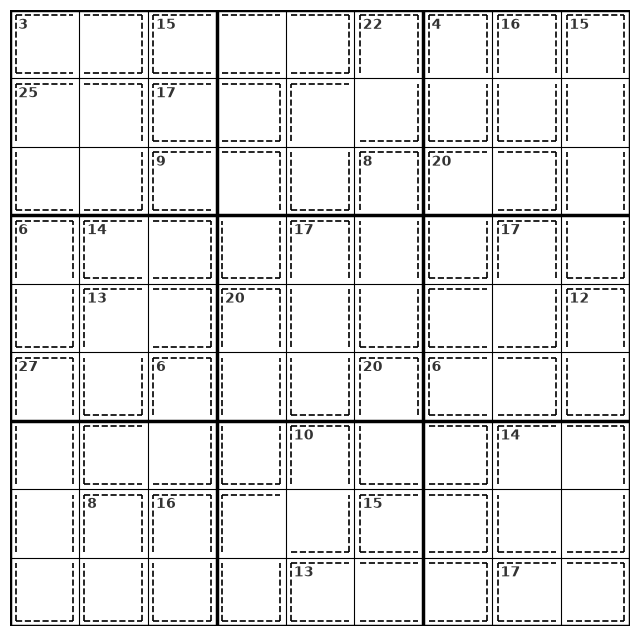

In [3]:
L = 3

# Matriz de dicas iniciais (caso haja números já preenchidos - neste desafio, não há dicas prévias)
dica = np.zeros((L**2, L**2))

# Lista de gaiolas com suas respectivas coordenadas (linha, coluna) e soma exigida
cages = [
    {'cells': [(0, 0), (0, 1)], 'sum': 3},
    {'cells': [(0, 2), (0, 3), (0, 4)], 'sum': 15},
    {'cells': [(0, 5), (1, 5), (1, 4), (2, 4)], 'sum': 22},
    {'cells': [(0, 6), (1, 6)], 'sum': 4},
    {'cells': [(0, 7), (1, 7)], 'sum': 16},
    {'cells': [(0, 8), (1, 8), (2, 8), (3, 8)], 'sum': 15},
    {'cells': [(1, 0), (1, 1), (2, 1), (2, 0)], 'sum': 25},
    {'cells': [(1, 2), (1, 3)], 'sum': 17},
    {'cells': [(2, 2), (2, 3), (3, 3)], 'sum': 9},
    {'cells': [(2, 5), (3, 5), (4, 5)], 'sum': 8},
    {'cells': [(2, 6), (2, 7), (3, 6)], 'sum': 20},
    {'cells': [(3, 0), (4, 0)], 'sum': 6},
    {'cells': [(3, 1), (3, 2)], 'sum': 14},
    {'cells': [(3, 4), (4, 4), (5, 4)], 'sum': 17},
    {'cells': [(3, 7), (4, 7), (4, 6)], 'sum': 17},
    {'cells': [(4, 1), (4, 2), (5, 1)], 'sum': 13},
    {'cells': [(4, 3), (5, 3), (6, 3)], 'sum': 20},
    {'cells': [(4, 8), (5, 8)], 'sum': 12},
    {'cells': [(5, 0), (6, 0), (7, 0), (8, 0)], 'sum': 27},
    {'cells': [(5, 2), (6, 2), (6, 1)], 'sum': 6},
    {'cells': [(5, 5), (6, 5), (6, 6)], 'sum': 20},
    {'cells': [(5, 6), (5, 7)], 'sum': 6},
    {'cells': [(6, 4), (7, 4), (7, 3), (8, 3)], 'sum': 10},
    {'cells': [(6, 7), (7, 7), (7, 8), (6, 8)], 'sum': 14},
    {'cells': [(7, 1), (8, 1)], 'sum': 8},
    {'cells': [(7, 2), (8, 2)], 'sum': 16},
    {'cells': [(7, 5), (7, 6)], 'sum': 15},
    {'cells': [(8, 4), (8, 5), (8, 6)], 'sum': 13},
    {'cells': [(8, 7), (8, 8)], 'sum': 17}
]

print(f"Total de gaiolas definidas: {len(cages)}")
display_killersudoku(dica=dica, sol=None, cages=cages, savefig=True, namefile='killersudoku_inicial.png')


## 5. Implementação do Modelo em PuLP e Execução do Solver

Instanciação das variáveis de decisão e incorporação programática de todas as famílias de restrições lineares canônicas. Em seguida, aciona-se o solver aberto **Coin-OR CBC** (`pulp.PULP_CBC_CMD`), garantindo portabilidade e reprodutibilidade sem necessidade de licenças proprietárias.


In [4]:
# 1. Criação das Variáveis de Decisão Binárias x[i, j, k]
x = {}
for i, j, k in it.product(range(L**2), repeat=3):
    x[i, j, k] = pulp.LpVariable(
        name=f"x_{i+1}_{j+1}_{k+1}",
        cat=pulp.LpBinary
    )

# 2. Inicialização do Problema de Satisfatibilidade de Restrições
problema = pulp.LpProblem("KillerSudoku_Optimization", pulp.LpMinimize)

# 3. Restrição 1: Cada célula (i, j) deve ter exatamente um número
for i, j in it.product(range(L**2), repeat=2):
    problema += pulp.lpSum(x[i, j, k] for k in range(L**2)) == 1

# 4. Restrição 2: Cada linha i deve conter cada dígito k exatamente uma vez
for i, k in it.product(range(L**2), repeat=2):
    problema += pulp.lpSum(x[i, j, k] for j in range(L**2)) == 1

# 5. Restrição 3: Cada coluna j deve conter cada dígito k exatamente uma vez
for j, k in it.product(range(L**2), repeat=2):
    problema += pulp.lpSum(x[i, j, k] for i in range(L**2)) == 1

# 6. Restrição 4: Cada subquadrado 3x3 deve conter cada dígito k exatamente uma vez
for I, J, k in it.product(range(L), range(L), range(L**2)):
    problema += pulp.lpSum(
        x[I * L + i, J * L + j, k] for i, j in it.product(range(L), repeat=2)
    ) == 1

# 7. Restrição 5: Cada gaiola deve conter no máximo uma ocorrência de cada dígito
for cage in cages:
    for k in range(L**2):
        problema += pulp.lpSum(x[i, j, k] for (i, j) in cage['cells']) <= 1

# 8. Restrição 6: A soma dos números dentro de cada gaiola deve ser igual a cage['sum']
for cage in cages:
    problema += pulp.lpSum(
        (k + 1) * x[i, j, k] for ((i, j), k) in it.product(cage['cells'], range(L**2))
    ) == cage['sum']

# 9. Inclusão de dicas iniciais (se houver)
for i, j in it.product(range(L**2), repeat=2):
    if dica[i, j] != 0:
        problema += (x[i, j, int(dica[i, j]) - 1] == 1)

# 10. Execução com o Solver Aberto CBC (com fallback para solver padrão PuLP)
solver = pulp.PULP_CBC_CMD(msg=False)
status = problema.solve(solver)

print(f"Status da Otimização: {pulp.LpStatus[problema.status]}")


Status da Otimização: Optimal


## 6. Extração da Matriz Solução e Renderização Final

Com a comprovação do status ótimo global (`Optimal`), extraem-se os valores das variáveis binárias para compor a matriz de números inteiros da solução e renderizar o tabuleiro final solucionado.


Matriz da Solução Encontrada:
[[2 1 5 6 4 7 3 9 8]
 [3 6 8 9 5 2 1 7 4]
 [7 9 4 3 8 1 6 5 2]
 [5 8 6 2 7 4 9 3 1]
 [1 4 2 5 9 3 8 6 7]
 [9 7 3 8 1 6 4 2 5]
 [8 2 1 7 3 9 5 4 6]
 [6 5 9 4 2 8 7 1 3]
 [4 3 7 1 6 5 2 8 9]]

Validação das somas das linhas (deve ser 45 para todas): True
Validação das somas das colunas (deve ser 45 para todas): True


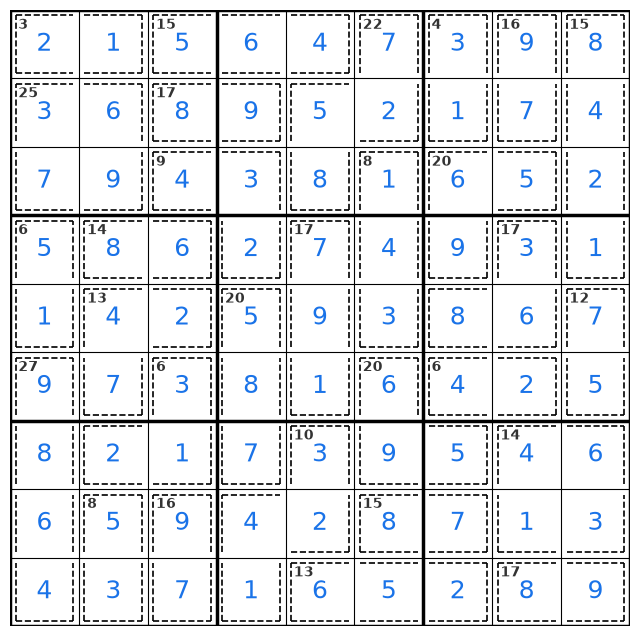

In [5]:
# Extração da solução a partir das variáveis binárias
solucao = np.empty((L**2, L**2), dtype=int)
for i, j, k in it.product(range(L**2), repeat=3):
    if x[i, j, k].value() and x[i, j, k].value() > 0.5:
        solucao[i, j] = k + 1

print("Matriz da Solução Encontrada:")
print(solucao)

# Validação: soma das linhas e colunas
somas_linhas = solucao.sum(axis=1)
somas_colunas = solucao.sum(axis=0)
print(f"\nValidação das somas das linhas (deve ser 45 para todas): {np.all(somas_linhas == 45)}")
print(f"Validação das somas das colunas (deve ser 45 para todas): {np.all(somas_colunas == 45)}")

# Renderização gráfica do tabuleiro resolvido
display_killersudoku(dica=np.zeros((L**2, L**2)), sol=solucao, cages=cages, savefig=True, namefile='solution_killersudoku.png')


## 7. Conclusões e Considerações de Pesquisa Operacional

1. **Eficiência da Modelagem Matemática**: A formulação com 729 variáveis binárias e restrições lineares exatas permitiu resolver um problema combinatório NP-difícil em menos de 1 segundo de CPU com o solver aberto CBC.
2. **Robustez das Restrições**: A combinação de unicidade de gaiolas com restrição de soma atua como fortes limitantes superiores e inferiores (*planos de corte*), podando o espaço de busca e conduzindo diretamente à solução única sem necessidade de heurísticas probabilísticas.
3. **Escalabilidade e Generalização**: A mesma metodologia é diretamente extensível a variações de Sudoku $16 \times 16$, Sudoku Diagonal e problemas industriais complexos de alocação de horários (*timetabling*), escalonamento de tripulações (*crew scheduling*) e roteamento logístico sob restrições.
